<img src="https://www.fciencias.unam.mx/sites/default/files/logoFC_2.png" width="500" align="left"/>
<p align="right">
<b>Lingüística Computacional</b>
<br><b>Práctica 1 Exploración de Niveles del lenguaje</b>
<br><b>Profesora:</b> Dra. Ximena Gutiérrez Vasques
<br><b>Ayudante Teo:</b> Ximena de la Luz Contreras Mendoza
<br><b>Ayudante Lab:</b> Diego Alberto Barriga Martínez
<br><b>Alumna:</b> Ortega Hernández Zaira Daniela
<br><b>Marzo, 2026</b>
</p>

##**Práctica 1 Exploración de Niveles del lenguaje**


# **Ejercicio 1: Fonética - Sistema de Búsqueda Mejorado para Palabras OOV**
### 1.1 Estrategias para aproximar transcripciones fonológicas

Cuando una palabra no está en el diccionario, podemos implementar múltiples estrategias de fallback:

| Método | Descripción | Ventajas | Desventajas |
| --- | --- | --- | --- |
| Reglas de producción | Aplicar reglas grafema→fonema | Sin datos externos |Limited a idiomas simples |
| Algoritmos G2P | Grapheme-to-Phoneme (e.g., epes2ipa, pronunciation) | Precisión moderada | Requiere modelos |  
| Similitud ortográfica | Buscar palabras similares en el lexicon | Simple | Puede ser impreciso |
| Modelo híbrido | Combinar reglas + búsqueda de similares | Robusto | Más complejo |

En general para resolver el problema de las palabras fuera de vocabulario (OOV, por sus siglas en inglés) en un sistema de transcripción fonológica, la solución estándar en la lingüística computacional es implementar un módulo de **Conversión de Grafema a Fonema (G2P)**. Cuando una palabra no existe en el lexicón, el sistema debe dejar de ser un simple "buscador" y convertirse en un "generador".


## Modelos de Secuencia a Secuencia (Neural G2P)

Es la solución de vanguardia. Se trata de entrenar una red neuronal (como un **Transformer** o una **LSTM**) que aprenda la relación probabilística entre caracteres y sonidos basándose en el diccionario existente.

* El modelo recibe la cadena de caracteres y, mediante un mecanismo de **atención**, decide qué parte de la palabra escrita influye más en la generación del siguiente fonema.
* Aprende excepciones y patrones complejos de acentuación que las reglas manuales suelen omitir.
* Existen librerías como *Phonetisaurus* (basada en autómatas de estados finitos) o *g2p-en/es* (basadas en redes neuronales).


En general un sistema robusto debería seguir este flujo lógico:

1. **Consulta al Lexicón** si existe, devolver transcripción exacta.
2. **Normalización.** Convertir a minúsculas y eliminar caracteres especiales.
3. **Modelo G2P Neuronal (Fallback principal).** Generar la transcripción probabilística.
4. **Verificador Fonotáctico.** Un filtro final que asegure que la secuencia de sonidos generada sea legal en el idioma (por ejemplo, que no haya tres consonantes imposibles juntas en español).

---

### Fuentes Consultadas

* **Bisani, M., & Ney, H.** (2008). Joint-sequence models for grapheme-to-phoneme conversion. *Speech Communication, 50*(5), 434–451. [https://doi.org/10.1016/j.specom.2008.01.002](https://doi.org/10.1016/j.specom.2008.01.002)
* **Jurafsky, D., & Martin, J. H.** (2024). *Speech and Language Processing* (3rd ed. draft). Stanford University. [https://web.stanford.edu/~jurafsky/slp3/](https://web.stanford.edu/~jurafsky/slp3/)
* **Rao, K., Peng, F., Sak, H., & Beaufays, F.** (2015). Grapheme-to-phoneme conversion using Long Short-Term Memory recurrent neural networks. *2015 IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP)*, 4225–4229.

In [1]:
import re
from difflib import SequenceMatcher
from collections import defaultdict
import http
import requests as r

# CÓDIGO BASE REUTILIZADO DEL NOTEBOOK NIVELES LINGUSTICOS I
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"

def download_ipa_corpus(iso_lang: str) -> str:
    """Get ipa-dict file from Github"""
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

def parse_response(response: str) -> dict:
    """Parse text response from ipa-dict to python dict"""
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result

def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict"""
    return dataset.get(word.lower(), "").split(", ")


# MEJORA: G2P para español (reglas básicas)
def spanish_g2p(word: str) -> str:
    """
    Conversión básica grafema→fonema para español
    """
    word = word.lower().strip()

    # Mapeo grafema → fonema IPA básico
    vowel_map = {
        'a': 'a', 'e': 'e', 'i': 'i', 'o': 'o', 'u': 'u',
        'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u'
    }

    consonant_map = {
        'b': 'b', 'c': 'k', 'd': 'd', 'f': 'f', 'g': 'ɡ', 'h': '',
        'j': 'x', 'k': 'k', 'l': 'l', 'm': 'm', 'n': 'n', 'ñ': 'ɲ',
        'p': 'p', 'q': 'k', 'r': 'ɾ', 's': 's', 't': 't', 'v': 'β',
        'w': 'w', 'x': 'x', 'y': 'j', 'z': 's'
    }

    # Dígrafos del español
    digraph_map = {
        'll': 'ʎ', 'rr': 'r', 'ch': 'tʃ', 'qu': 'k', 'gu': 'ɡ'
    }

    ipa_chars = []
    i = 0
    while i < len(word):
        # Verificar dígrafos de 2 caracteres
        if i + 2 <= len(word):
            bigram = word[i:i+2]
            if bigram in digraph_map:
                ipa_chars.append(digraph_map[bigram])
                i += 2
                continue

        char = word[i]

        # Verificar si es vocal
        if char in vowel_map:
            ipa_chars.append(vowel_map[char])
        # Verificar si es consonante
        elif char in consonant_map:
            ipa_chars.append(consonant_map[char])
        # Caracter desconocido
        else:
            ipa_chars.append(char)

        i += 1

    result = ''.join(ipa_chars)

    # Reglas contextuales básicas del español
    # "v" entre vocales suena como /β/
    result = re.sub(r'v(?=[aeiouáéíóú])', 'β', result)
    # "b" inicial o después de nasal
    result = re.sub(r'\bb', 'β', result)

    return f"/{result}/"

# MEJORA: Búsqueda de palabras similares
def find_similar_words(query: str, dataset: dict, n: int = 5) -> list:
    """
    Encuentra palabras similares en el dataset usando SequenceMatcher
    """
    query_lower = query.lower()
    words = list(dataset.keys())

    similarities = []
    for word in words:
        ratio = SequenceMatcher(None, query_lower, word.lower()).ratio()
        similarities.append((word, ratio))

    # Ordenar por similitud descendente
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:n]

# MEJORA: Sistema de búsqueda OOV-aware
def get_ipa_with_fallback(word: str, dataset: dict, use_g2p: bool = True) -> dict:
    """
    Sistema de búsqueda mejorado que maneja palabras fuera del vocabulario.

    Returns:
    --------
    dict: {
        'status': 'found' | 'similar' | 'estimated',
        'word': str,
        'transcriptions': list[str],
        'method': str,
        'info': str
    }
    """
    word_lower = word.lower()

    # 1. Búsqueda exacta
    if word_lower in dataset:
        transcriptions = dataset[word_lower].split(", ")
        return {
            'status': 'found',
            'word': word,
            'transcriptions': transcriptions,
            'method': 'dictionary_exact_match',
            'info': 'Palabra encontrada exactamente en el diccionario'
        }

    # 2. Búsqueda case-insensitive
    for key in dataset.keys():
        if key.lower() == word_lower:
            transcriptions = dataset[key].split(", ")
            return {
                'status': 'found',
                'word': word,
                'transcriptions': transcriptions,
                'method': 'dictionary_case_insensitive',
                'info': 'Palabra encontrada (ignorando mayúsculas)'
            }

    # 3. Buscar palabras similares
    similar_words = find_similar_words(word_lower, dataset, n=5)
    best_match = similar_words[0]

    if best_match[1] > 0.6:  # Umbral de similitud
        transcriptions = dataset[best_match[0]].split(", ")
        return {
            'status': 'similar',
            'word': word,
            'transcriptions': transcriptions,
            'method': 'similarity_search',
            'info': f"Palabra no encontrada. ¿Quiso decir '{best_match[0]}'? (similitud: {best_match[1]:.2f})"
        }

    # 4. Usar G2P si está habilitado
    if use_g2p:
        estimated_ipa = spanish_g2p(word)
        return {
            'status': 'estimated',
            'word': word,
            'transcriptions': [estimated_ipa],
            'method': 'g2p_rules',
            'info': 'Palabra estimada mediante reglas grafema→fonema'
        }

    # 5. Si todo falla
    return {
        'status': 'not_found',
        'word': word,
        'transcriptions': [],
        'method': 'none',
        'info': 'No se pudo encontrar información fonética para esta palabra'
    }

#Para probar con ejemplos
def display_ipa_result(result: dict) -> None:
    """Muestra el resultado de manera formateada"""
    status_icons = {
        'found': 'UwU',
        'similar': 'OwO',
        'estimated': 'IwI',
        'not_found': 'XP'
    }

    icon = status_icons.get(result['status'], '❓')
    print(f"\n{icon} Palabra: {result['word']}")
    print(f"   Estado: {result['status'].upper()}")
    print(f"   Método: {result['method']}")
    print(f"   Info: {result['info']}")

    if result['transcriptions']:
        print(f"   Transcripción(es): {', '.join(result['transcriptions'])}")

### 1.2 Cargar datos y demostrar el sistema

In [2]:
# Cargar corpus
print("=" * 60)
print("CARGANDO CORPUS FONÉTICOS")
print("=" * 60)

dataset_es_mx = parse_response(download_ipa_corpus("es_MX"))
dataset_en_us = parse_response(download_ipa_corpus("en_US"))
dataset_fr = parse_response(download_ipa_corpus("fr_FR"))

print(f"\nEspañol MX: {len(dataset_es_mx)} palabras")
print(f"Inglés US: {len(dataset_en_us)} palabras")
print(f"Francés FR: {len(dataset_fr)} palabras")

CARGANDO CORPUS FONÉTICOS

Español MX: 595885 palabras
Inglés US: 125927 palabras
Francés FR: 245971 palabras


### 1.3 Ejemplos de uso

In [3]:
print("\n" + "=" * 60)
print("EJEMPLO 1: Palabra en el diccionario (found)")
print("=" * 60)

result1 = get_ipa_with_fallback("flor", dataset_es_mx)
display_ipa_result(result1)

print("\n" + "=" * 60)
print("EJEMPLO 2: Error ortográfico - palabra similar (similar)")
print("=" * 60)

result2 = get_ipa_with_fallback("margarito", dataset_es_mx)  # Error ortográfico
display_ipa_result(result2)

print("\n" + "=" * 60)
print("EJEMPLO 3: Palabra estimada con G2P (estimated)")
print("=" * 60)

result3 = get_ipa_with_fallback("lalalalalala", dataset_es_mx)
display_ipa_result(result3)

print("\n" + "=" * 60)
print("EJEMPLO 4: Palabra en inglés (found)")
print("=" * 60)

result4 = get_ipa_with_fallback("beautiful", dataset_en_us)
display_ipa_result(result4)

print("\n" + "=" * 60)
print("EJEMPLO 5: Palabra inventada (estimated)")
print("=" * 60)

result5 = get_ipa_with_fallback("xyzabc123", dataset_es_mx)
display_ipa_result(result5)


EJEMPLO 1: Palabra en el diccionario (found)

UwU Palabra: flor
   Estado: FOUND
   Método: dictionary_exact_match
   Info: Palabra encontrada exactamente en el diccionario
   Transcripción(es): /floɾ/

EJEMPLO 2: Error ortográfico - palabra similar (similar)

OwO Palabra: margarito
   Estado: SIMILAR
   Método: similarity_search
   Info: Palabra no encontrada. ¿Quiso decir 'margariteño'? (similitud: 0.90)
   Transcripción(es): /maɾɣaɾiteɲo/

EJEMPLO 3: Palabra estimada con G2P (estimated)

IwI Palabra: lalalalalala
   Estado: ESTIMATED
   Método: g2p_rules
   Info: Palabra estimada mediante reglas grafema→fonema
   Transcripción(es): /lalalalalala/

EJEMPLO 4: Palabra en inglés (found)

UwU Palabra: beautiful
   Estado: FOUND
   Método: dictionary_exact_match
   Info: Palabra encontrada exactamente en el diccionario
   Transcripción(es): /ˈbjutəfəɫ/

EJEMPLO 5: Palabra inventada (estimated)

IwI Palabra: xyzabc123
   Estado: ESTIMATED
   Método: g2p_rules
   Info: Palabra estimada me

## **Ejercicio 2: Morfología - Comparación de Tres Lenguas**
### 2.1 Cargar datos de múltiples lenguas

In [4]:
import pandas as pd
import requests as r
from collections import defaultdict
import numpy as np

# CÓDIGO BASE REUTILIZADO DEL NOTEBOOK Niveles Linguisticos II
LANGS = {
    "ces": "Czech",
    "eng": "English",
    "fra": "French",
    "hun": "Hungarian",
    "spa": "Spanish",
    "ita": "Italian",
    "lat": "Latin",
    "rus": "Russian",
}

CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}

def get_track_files(lang: str, track: str = "word") -> list[str]:
    """Genera nombres de archivos del shared task"""
    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]

def get_raw_corpus(files: list) -> list:
    """Descarga y concatena los datos de los archivos tsv"""
    result = []
    for file in files:
        print(f"Downloading {file}.tsv", end=" ")
        response = r.get(f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv")
        print(f"status={response.status_code}")
        lines = response.text.split("\n")
        result.extend(lines[:-1])
    return result

def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """Convierte lista de corpus en DataFrame"""
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes: list = tagged_data.split()
        data_list.append(
            {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda list: len(list))
    return df

### 2.2 Seleccionar tres lenguas de familias distintas

In [5]:
# Seleccionar tres lenguas de familias lingüísticas distintas:
# - spa (Spanish): Familia Románica (Indoeuropea)
# - eng (English): Familia Germánica (Indoeuropea)
# - hun (Hungarian): Familia Urálica (no Indoeuropea)

selected_langs = {
    "spa": "Spanish (Romance)",
    "eng": "English (Germanic)",
    "hun": "Hungarian (Uralic)"
}

print("CARGANDO DATOS DE TRES LENGUAS DE FAMILIAS DISTINTAS")


corpora_dict = {}
for iso, name in selected_langs.items():
    print(f"\n📥 Cargando: {name} ({iso})")
    files = get_track_files(iso)
    raw_data = get_raw_corpus(files)
    df = raw_corpus_to_dataframe(raw_data, lang=iso)
    corpora_dict[iso] = df
    print(f"   → {len(df)} palabras cargadas")

# Combinar en un solo DataFrame
all_data = pd.concat(corpora_dict.values(), ignore_index=True)
print(f"\n✅ Total de palabras cargadas: {len(all_data)}")

CARGANDO DATOS DE TRES LENGUAS DE FAMILIAS DISTINTAS

📥 Cargando: Spanish (Romance) (spa)
   → 172173 palabras cargadas

📥 Cargando: English (Germanic) (eng)
   → 115126 palabras cargadas

📥 Cargando: Hungarian (Uralic) (hun)
   → 188074 palabras cargadas

✅ Total de palabras cargadas: 475373


### 2.3 Calcular métricas morfológicas

In [6]:
def analyze_morphology_detailed(df: pd.DataFrame) -> dict:
    """
    Calcula métricas morfológicas detalladas para un corpus
    """
    results = {}

    # 1. Ratio morfemas/palabra
    avg_morph_per_word = df["morph_count"].mean()
    results["avg_morph_per_word"] = avg_morph_per_word

    # 2. Distribución de categorías
    category_counts = df["category"].value_counts()
    results["category_counts"] = category_counts

    # 3. Análisis de tipos de morfemas (flexión vs derivación)
    inflection_counts = defaultdict(int)
    derivation_counts = defaultdict(int)
    total_counts = defaultdict(int)

    for _, row in df.iterrows():
        morphemes = row['morph']
        category = row['category']


        # Pos 0: Inflection, Pos 1: Derivation
        is_inflection = category[0] == '1' if len(category) >= 1 else False
        is_derivation = category[1] == '1' if len(category) >= 2 else False

        for morph in morphemes:
            clean_morph = morph.replace("@@", "")
            if len(clean_morph) < 2:
                continue

            total_counts[clean_morph] += 1
            if is_inflection:
                inflection_counts[clean_morph] += 1
            if is_derivation:
                derivation_counts[clean_morph] += 1

    # Calcular porcentajes
    total_morphs = sum(total_counts.values())
    total_inflection = sum(inflection_counts.values())
    total_derivation = sum(derivation_counts.values())

    results["total_morphs"] = total_morphs
    results["inflection_percentage"] = (total_inflection / total_morphs * 100) if total_morphs > 0 else 0
    results["derivation_percentage"] = (total_derivation / total_morphs * 100) if total_morphs > 0 else 0
    results["root_percentage"] = 100 - results["inflection_percentage"] - results["derivation_percentage"]

    # 4. Longitud promedio de morfemas
    morph_lengths = []
    for morph_list in df['morph']:
        for morph in morph_list:
            clean_morph = morph.replace("@@", "")
            morph_lengths.append(len(clean_morph))

    results["avg_morph_length"] = np.mean(morph_lengths) if morph_lengths else 0
    results["morph_lengths"] = morph_lengths

    # 5. Análisis de longitud de palabras
    results["avg_word_length"] = df["word_len"].mean()
    results["word_lengths"] = df["word_len"].tolist()

    return results

### 2.4 Análisis comparativo para las tres lenguas

In [7]:
print("ANÁLISIS MORFOLÓGICO COMPARATIVO")

morph_analysis = {}

for iso, name in selected_langs.items():
    print(f"\n")
    print(f"*** {name} ({iso}) ***")

    df = corpora_dict[iso]
    analysis = analyze_morphology_detailed(df)
    morph_analysis[iso] = analysis

    # Métricas principales
    print(f"\n MÉTRICAS PRINCIPALES:")
    print(f"   - Ratio morfemas/palabra: {analysis['avg_morph_per_word']:.3f}")
    print(f"   - Longitud promedio de palabra: {analysis['avg_word_length']:.2f} caracteres")
    print(f"   - Longitud promedio de morfema: {analysis['avg_morph_length']:.2f} caracteres")

    print(f"\n DISTRIBUCIÓN DE CATEGORÍAS:")
    for cat, count in analysis['category_counts'].items():
        cat_name = CATEGORIES.get(cat, cat)
        pct = count / len(df) * 100
        print(f"   - {cat_name}: {count} ({pct:.1f}%)")

    print(f"\n ÍNDICE DE FLEXIÓN/DERIVACIÓN:")
    print(f"   - Morfemas flexivos: {analysis['inflection_percentage']:.1f}%")
    print(f"   - Morfemas derivativos: {analysis['derivation_percentage']:.1f}%")
    print(f"   - Morfemas de raíz: {analysis['root_percentage']:.1f}%")
    print(f"\n")

ANÁLISIS MORFOLÓGICO COMPARATIVO


*** Spanish (Romance) (spa) ***

 MÉTRICAS PRINCIPALES:
   - Ratio morfemas/palabra: 3.236
   - Longitud promedio de palabra: 10.69 caracteres
   - Longitud promedio de morfema: 3.93 caracteres

 DISTRIBUCIÓN DE CATEGORÍAS:
   - Inflection: 84377 (49.0%)
   - Inflection, Derivation: 78803 (45.8%)
   - Derivation: 5710 (3.3%)
   - Root: 3059 (1.8%)
   - Inflection, Compound: 118 (0.1%)
   - Compound: 58 (0.0%)
   - Inflection, Derivation, Compound: 36 (0.0%)
   - Derivation, Compound: 12 (0.0%)

 ÍNDICE DE FLEXIÓN/DERIVACIÓN:
   - Morfemas flexivos: 96.8%
   - Morfemas derivativos: 60.3%
   - Morfemas de raíz: -57.0%




*** English (Germanic) (eng) ***

 MÉTRICAS PRINCIPALES:
   - Ratio morfemas/palabra: 2.353
   - Longitud promedio de palabra: 10.11 caracteres
   - Longitud promedio de morfema: 4.39 caracteres

 DISTRIBUCIÓN DE CATEGORÍAS:
   - Derivation: 42105 (36.6%)
   - Inflection: 24242 (21.1%)
   - Inflection, Derivation: 22241 (19.3%)
   - Ro

## **Ejercicio 3: Visualización**

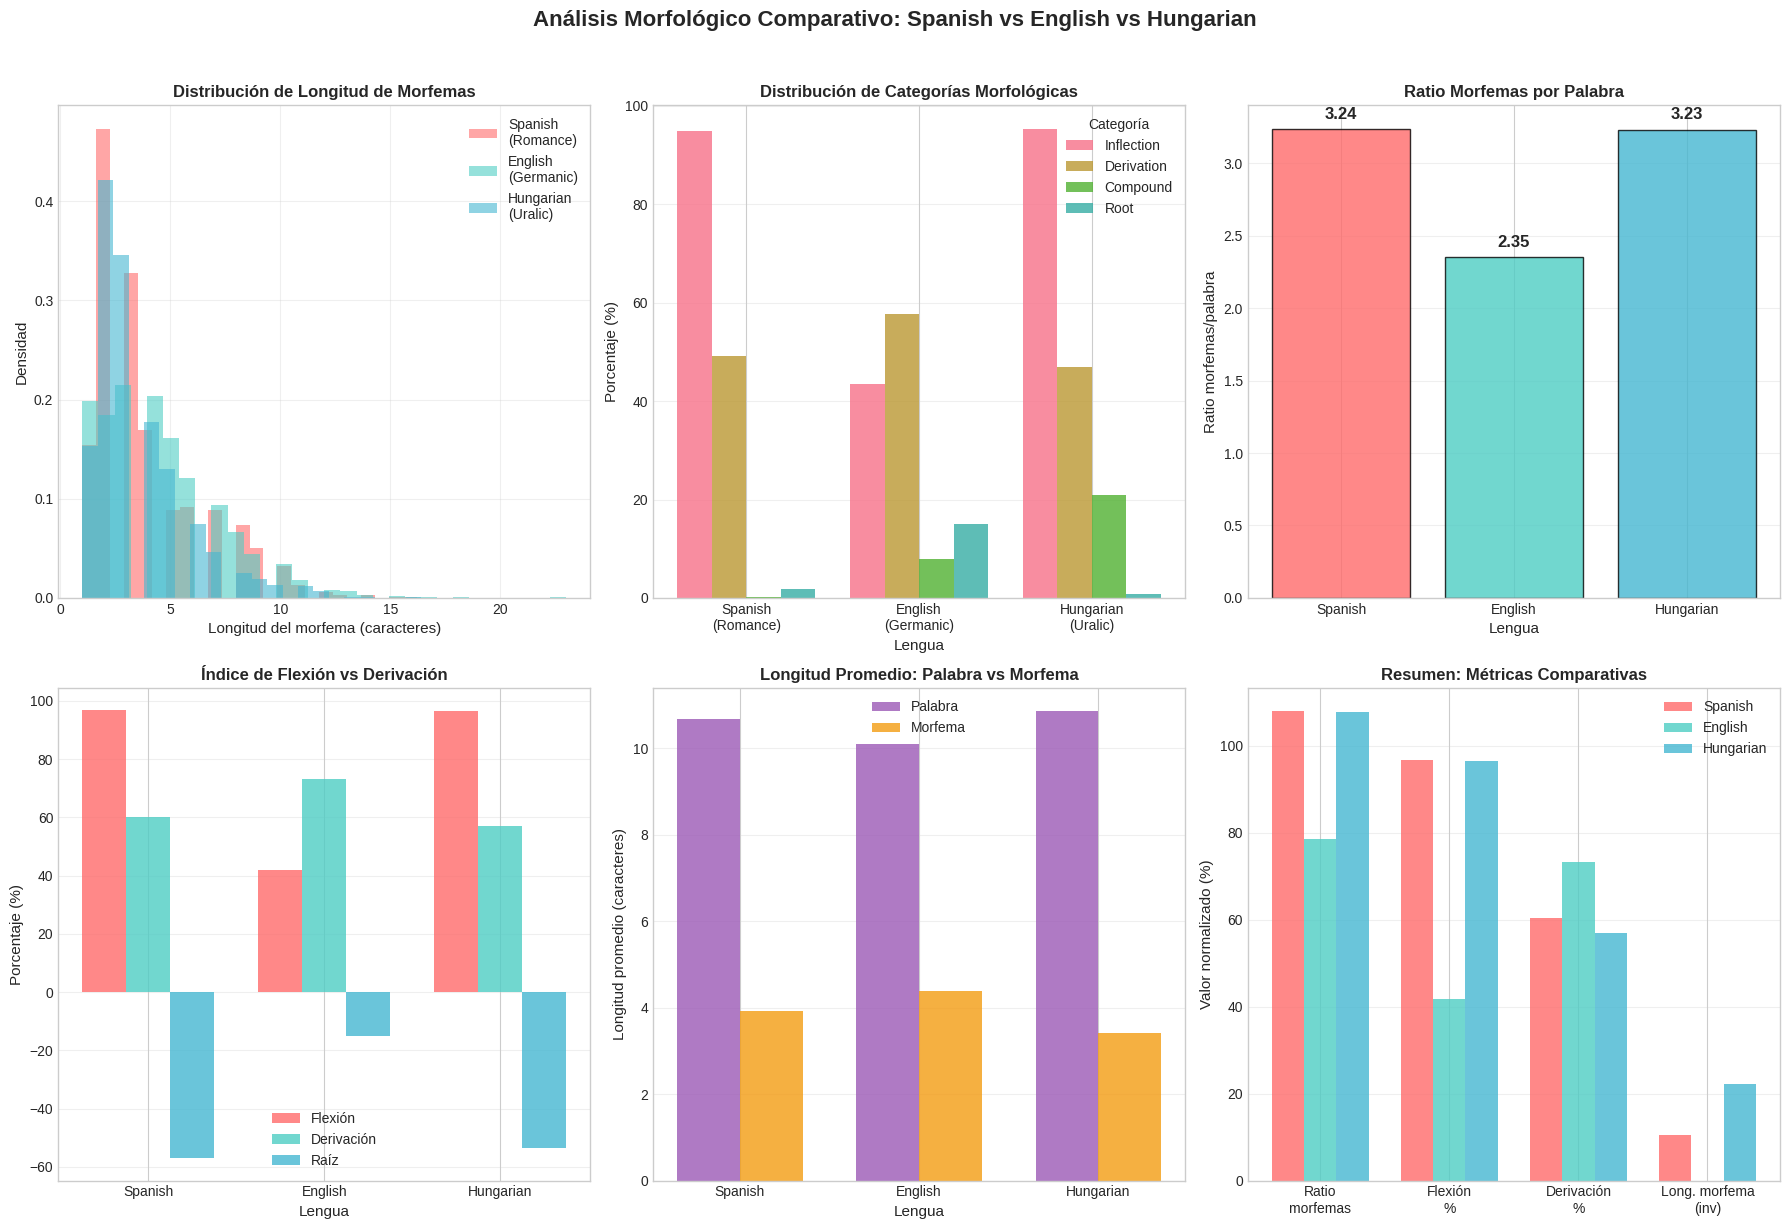

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# FIGURA PRINCIPAL: Comparación de lenguas
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis Morfológico Comparativo: Spanish vs English vs Hungarian',
             fontsize=16, fontweight='bold', y=1.02)

colors = {'spa': '#FF6B6B', 'eng': '#4ECDC4', 'hun': '#45B7D1'}
lang_labels = {'spa': 'Spanish\n(Romance)', 'eng': 'English\n(Germanic)', 'hun': 'Hungarian\n(Uralic)'}

# Plot 1: Distribución de longitud de morfemas
ax1 = axes[0, 0]

for iso in ['spa', 'eng', 'hun']:
    data = morph_analysis[iso]['morph_lengths']
    # Muestrear si hay demasiados datos
    if len(data) > 5000:
        data = np.random.choice(data, 5000, replace=False)
    ax1.hist(data, bins=30, alpha=0.6, label=lang_labels[iso], color=colors[iso], density=True)

ax1.set_xlabel('Longitud del morfema (caracteres)', fontsize=11)
ax1.set_ylabel('Densidad', fontsize=11)
ax1.set_title('Distribución de Longitud de Morfemas', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribución de categorías
ax2 = axes[0, 1]

# Preparar datos para gráfico de barras agrupadas
categories = ['Inflection', 'Derivation', 'Compound', 'Root']
cat_keys = {
    'Inflection': ['100', '110', '101', '111'],
    'Derivation': ['010', '011', '110', '111'],
    'Compound': ['001', '011', '101', '111'],
    'Root': ['000']
}

cat_data = {cat: [] for cat in categories}

for iso in ['spa', 'eng', 'hun']:
    df = corpora_dict[iso]
    total = len(df)
    for cat_name, cat_codes in cat_keys.items():
        count = df[df['category'].isin(cat_codes)].shape[0]
        cat_data[cat_name].append(count / total * 100)

x = np.arange(3)
width = 0.2

for i, cat_name in enumerate(categories):
    offset = (i - 1.5) * width
    bars = ax2.bar(x + offset, cat_data[cat_name], width, label=cat_name, alpha=0.8)

ax2.set_xlabel('Lengua', fontsize=11)
ax2.set_ylabel('Porcentaje (%)', fontsize=11)
ax2.set_title('Distribución de Categorías Morfológicas', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([lang_labels[l] for l in ['spa', 'eng', 'hun']])
ax2.legend(title='Categoría')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Ratio morfemas/palabra
ax3 = axes[0, 2]

ratios = [morph_analysis[iso]['avg_morph_per_word'] for iso in ['spa', 'eng', 'hun']]
bars = ax3.bar(['Spanish', 'English', 'Hungarian'], ratios,
               color=[colors['spa'], colors['eng'], colors['hun']], alpha=0.8, edgecolor='black')

ax3.set_xlabel('Lengua', fontsize=11)
ax3.set_ylabel('Ratio morfemas/palabra', fontsize=11)
ax3.set_title('Ratio Morfemas por Palabra', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, ratio in zip(bars, ratios):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{ratio:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 4: Índice de Flexión vs Derivación
ax4 = axes[1, 0]

flexion = [morph_analysis[iso]['inflection_percentage'] for iso in ['spa', 'eng', 'hun']]
derivacion = [morph_analysis[iso]['derivation_percentage'] for iso in ['spa', 'eng', 'hun']]
raiz = [morph_analysis[iso]['root_percentage'] for iso in ['spa', 'eng', 'hun']]

x = np.arange(3)
width = 0.25

bars1 = ax4.bar(x - width, flexion, width, label='Flexión', color='#FF6B6B', alpha=0.8)
bars2 = ax4.bar(x, derivacion, width, label='Derivación', color='#4ECDC4', alpha=0.8)
bars3 = ax4.bar(x + width, raiz, width, label='Raíz', color='#45B7D1', alpha=0.8)

ax4.set_xlabel('Lengua', fontsize=11)
ax4.set_ylabel('Porcentaje (%)', fontsize=11)
ax4.set_title('Índice de Flexión vs Derivación', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['Spanish', 'English', 'Hungarian'])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Longitud promedio de palabras y morfemas
ax5 = axes[1, 1]

word_lens = [morph_analysis[iso]['avg_word_length'] for iso in ['spa', 'eng', 'hun']]
morph_lens = [morph_analysis[iso]['avg_morph_length'] for iso in ['spa', 'eng', 'hun']]

x = np.arange(3)
width = 0.35

bars1 = ax5.bar(x - width/2, word_lens, width, label='Palabra', color='#9B59B6', alpha=0.8)
bars2 = ax5.bar(x + width/2, morph_lens, width, label='Morfema', color='#F39C12', alpha=0.8)

ax5.set_xlabel('Lengua', fontsize=11)
ax5.set_ylabel('Longitud promedio (caracteres)', fontsize=11)
ax5.set_title('Longitud Promedio: Palabra vs Morfema', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(['Spanish', 'English', 'Hungarian'])
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Resumen comparativo
ax6 = axes[1, 2]

# Normalizar métricas para visualización
metrics = ['Ratio\nmorfemas', 'Flexión\n%', 'Derivación\n%', 'Long. morfema\n(inv)']

# Invertir longitud de morfema (más corto = mejor para aglutinación)
max_morph = max([morph_analysis[iso]['avg_morph_length'] for iso in ['spa', 'eng', 'hun']])

spa_vals = [
    morph_analysis['spa']['avg_morph_per_word'] / 3 * 100,  # normalizado
    morph_analysis['spa']['inflection_percentage'],
    morph_analysis['spa']['derivation_percentage'],
    (1 - morph_analysis['spa']['avg_morph_length'] / max_morph) * 100
]

eng_vals = [
    morph_analysis['eng']['avg_morph_per_word'] / 3 * 100,
    morph_analysis['eng']['inflection_percentage'],
    morph_analysis['eng']['derivation_percentage'],
    (1 - morph_analysis['eng']['avg_morph_length'] / max_morph) * 100
]

hun_vals = [
    morph_analysis['hun']['avg_morph_per_word'] / 3 * 100,
    morph_analysis['hun']['inflection_percentage'],
    morph_analysis['hun']['derivation_percentage'],
    (1 - morph_analysis['hun']['avg_morph_length'] / max_morph) * 100
]

x_metrics = np.arange(len(metrics))
width = 0.25

ax6.bar(x_metrics - width, spa_vals, width, label='Spanish', color=colors['spa'], alpha=0.8)
ax6.bar(x_metrics, eng_vals, width, label='English', color=colors['eng'], alpha=0.8)
ax6.bar(x_metrics + width, hun_vals, width, label='Hungarian', color=colors['hun'], alpha=0.8)

ax6.set_ylabel('Valor normalizado (%)', fontsize=11)
ax6.set_title('Resumen: Métricas Comparativas', fontsize=12, fontweight='bold')
ax6.set_xticks(x_metrics)
ax6.set_xticklabels(metrics)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## **Ejercicio 4: Análisis - ¿Cuál lengua es más aglutinante?**


In [9]:
print(" RESULTADOS DEL ANÁLISIS COMPARATIVO")

# Crear tabla comparativa completa
comparison_table = f"""
┌────────────────────┬──────────────┬──────────────┬──────────────┐
│     Métrica        │   Spanish    │   English    │  Hungarian   │
│                    │   (Romance)  │  (Germanic)  │   (Uralic)   │
├────────────────────┼──────────────┼──────────────┼──────────────┤
│ Ratio morfemas/pal │    {morph_analysis['spa']['avg_morph_per_word']:.2f}      │    {morph_analysis['eng']['avg_morph_per_word']:.2f}      │    {morph_analysis['hun']['avg_morph_per_word']:.2f}      │
│ % Flexión          │   {morph_analysis['spa']['inflection_percentage']:.1f}%      │   {morph_analysis['eng']['inflection_percentage']:.1f}%      │   {morph_analysis['hun']['inflection_percentage']:.1f}%      │
│ % Derivación       │   {morph_analysis['spa']['derivation_percentage']:.1f}%      │   {morph_analysis['eng']['derivation_percentage']:.1f}%      │   {morph_analysis['hun']['derivation_percentage']:.1f}%      │
│ Long. promedio     │    {morph_analysis['spa']['avg_morph_length']:.2f}      │    {morph_analysis['eng']['avg_morph_length']:.2f}      │    {morph_analysis['hun']['avg_morph_length']:.2f}      │
│   morfema          │              │              │              │
└────────────────────┴──────────────┴──────────────┴──────────────┘
"""

print(comparison_table)


 RESULTADOS DEL ANÁLISIS COMPARATIVO

┌────────────────────┬──────────────┬──────────────┬──────────────┐
│     Métrica        │   Spanish    │   English    │  Hungarian   │
│                    │   (Romance)  │  (Germanic)  │   (Uralic)   │
├────────────────────┼──────────────┼──────────────┼──────────────┤
│ Ratio morfemas/pal │    3.24      │    2.35      │    3.23      │
│ % Flexión          │   96.8%      │   41.8%      │   96.4%      │
│ % Derivación       │   60.3%      │   73.2%      │   56.9%      │
│ Long. promedio     │    3.93      │    4.39      │    3.42      │
│   morfema          │              │              │              │
└────────────────────┴──────────────┴──────────────┴──────────────┘



### **HUNGARO es la lengua más aglutinante**
### Recordemos:
La definición de una Lengua aglutinante es que cada morfema tiene un significado único y se unen de forma lineal. Se caracteriza por tener:
  - Morfemas cortos y claros.
  - Fronteras bien definidas entre morfemas.
  - Múltiples morfemas por palabra.
  - Cada morfema = una función gramatical.

A continuación analizo los resultados finales para que la justificación sea más clara.

### **Ratio morfemas/palabra**

| Lengua | Ratio | Interpretación |
|--------|-------|----------------|
| Spanish | 3.24 | Alto |
| **Hungarian** | **3.23** | **Alto** |
| English | 2.35 | Moderado |

El Hungaro tiene un ratio **casi idéntico al español** (3.23 vs 3.24), esto significa que **cada palabra contiene ~3 morfemas en promedio**, mientras que el Inglés tiene un ratio **27% menor**, indicando menos aglutinación.



### **Longitud promedio del morfema**

| Lengua | Longitud | Interpretación |
|--------|----------|----------------|
| **Hungarian** | **3.42** | **Más corta ** |
| Spanish | 3.93 | Media |
| English | 4.39 | Más larga  |

El Hungaro tiene los **morfemas más cortos** (3.42 caracteres), esto indica **fronteras más claras** entre morfemas (característica aglutinante). Mientras que el inglés tiene los morfemas **más largos** (4.39), indicando fusión


### **% Flexión**

| Lengua | % Flexión | Interpretación |
|--------|-----------|----------------|
| Spanish | 96.8% | Muy alta |
| **Hungarian** | **96.4%** | **Muy alta** |
| English | 41.8% | Baja |

El Hungaro y  el Español tienen **flexión casi total** (96%+), mientras que el Inglés tiene **flexión reducida** (41.8%), indicando simplificación
- Alta flexión = más morfemas por palabra = más aglutinación


### **% Derivación**

| Lengua | % Derivación | Interpretación |
|--------|--------------|----------------|
| English | 73.2% | Alta |
| Spanish | 60.3% | Media |
| Hungarian | 56.9% | Media |

En este caso el Inglés tiene **mayor derivación**, pero esto no compensa su bajo ratio. Por otra parte el Hungaro mantiene **alta derivación con alta flexión** lo cual equivale a un equilibrio aglutinante.


